# Exercise 06 — Karate Club Split


In [ ]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

G = nx.karate_club_graph()

print("Karate Club graph")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Density:", round(nx.density(G), 4))
print("Connected:", nx.is_connected(G))

Karate Club graph
Nodes: 34
Edges: 78
Density: 0.139
Connected: True


## 2. Erdős–Rényi baseline

The ER graph uses the same number of nodes and approximately the same edge probability as the real graph.

The probability is chosen using the density of the Karate Club network.


In [ ]:
n = G.number_of_nodes()
p = nx.density(G)

ER = nx.erdos_renyi_graph(n=n, p=p, seed=42)

print("ER graph")
print("Nodes:", ER.number_of_nodes())
print("Edges:", ER.number_of_edges())
print("Density:", round(nx.density(ER), 4))
print("Connected:", nx.is_connected(ER))

ER graph
Nodes: 34
Edges: 81
Density: 0.1444
Connected: True


## 3. Degree distribution comparison

We compare how node degrees are distributed in the real network and in the ER baseline.


In [ ]:
real_degrees = [d for _, d in G.degree()]
er_degrees = [d for _, d in ER.degree()]

degree_df = pd.DataFrame({
    "metric": ["Minimum degree", "Maximum degree", "Average degree"],
    "Karate Club": [
        min(real_degrees),
        max(real_degrees),
        round(np.mean(real_degrees), 2)
    ],
    "ER baseline": [
        min(er_degrees),
        max(er_degrees),
        round(np.mean(er_degrees), 2)
    ]
})

degree_df

,metric,Karate Club,ER baseline
0,Minimum degree,1.00,2.00
1,Maximum degree,17.00,8.00
2,Average degree,4.59,4.76


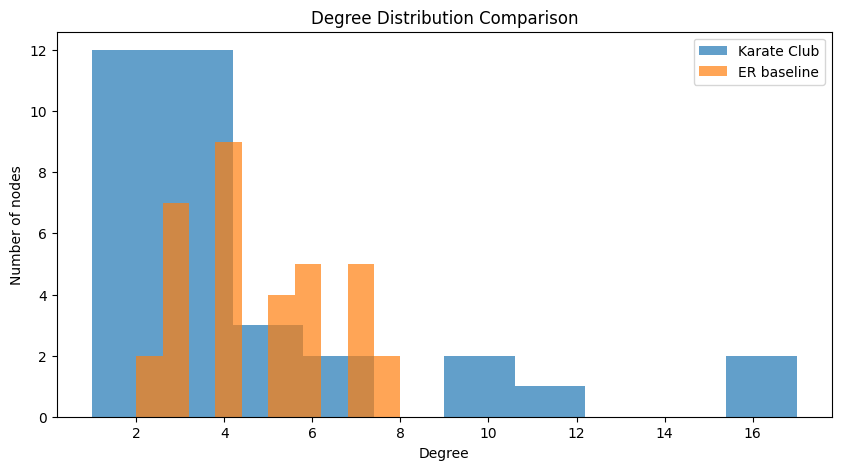

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(real_degrees, bins=10, alpha=0.7, label="Karate Club")
plt.hist(er_degrees, bins=10, alpha=0.7, label="ER baseline")

plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.title("Degree Distribution Comparison")
plt.legend()
plt.show()

## 4. Clustering comparison

Average clustering measures how strongly friends of a node are connected to each other.


In [ ]:
real_clustering = nx.average_clustering(G)
er_clustering = nx.average_clustering(ER)

clustering_df = pd.DataFrame({
    "Graph": ["Karate Club", "ER baseline"],
    "Average clustering": [real_clustering, er_clustering]
})

clustering_df

,Graph,Average clustering
0,Karate Club,0.570638
1,ER baseline,0.120518


## 5. Average path length comparison

Path-based metrics require a connected graph.

If the ER graph is disconnected, we compute the metric on its largest connected component and clearly report that choice.


In [ ]:
real_path_length = nx.average_shortest_path_length(G)

if nx.is_connected(ER):
    ER_path_graph = ER
    er_path_note = "Full ER graph"
else:
    largest_component = max(nx.connected_components(ER), key=len)
    ER_path_graph = ER.subgraph(largest_component).copy()
    er_path_note = "Largest connected component of ER graph"

er_path_length = nx.average_shortest_path_length(ER_path_graph)

path_df = pd.DataFrame({
    "Graph": ["Karate Club", "ER baseline"],
    "Average shortest path length": [
        real_path_length,
        er_path_length
    ]
})

print("ER path metric calculated on:", er_path_note)
path_df

ER path metric calculated on: Full ER graph


,Graph,Average shortest path length
0,Karate Club,2.408200
1,ER baseline,2.351159


## 6. Largest connected component comparison

We compare the size of the largest connected component in both graphs.


In [ ]:
real_lcc = len(max(nx.connected_components(G), key=len))
er_lcc = len(max(nx.connected_components(ER), key=len))

lcc_df = pd.DataFrame({
    "Graph": ["Karate Club", "ER baseline"],
    "Largest connected component size": [
        real_lcc,
        er_lcc
    ]
})

lcc_df

,Graph,Largest connected component size
0,Karate Club,34
1,ER baseline,34


## 7. Combined comparison table


In [ ]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Nodes",
        "Edges",
        "Density",
        "Average degree",
        "Maximum degree",
        "Average clustering",
        "Average shortest path length",
        "Largest connected component"
    ],
    "Karate Club": [
        G.number_of_nodes(),
        G.number_of_edges(),
        nx.density(G),
        np.mean(real_degrees),
        max(real_degrees),
        real_clustering,
        real_path_length,
        real_lcc
    ],
    "ER baseline": [
        ER.number_of_nodes(),
        ER.number_of_edges(),
        nx.density(ER),
        np.mean(er_degrees),
        max(er_degrees),
        er_clustering,
        er_path_length,
        er_lcc
    ]
})

comparison_df

,Metric,Karate Club,ER baseline
0,Nodes,34.000000,34.000000
1,Edges,78.000000,81.000000
2,Density,0.139037,0.144385
3,Average degree,4.588235,4.764706
4,Maximum degree,17.000000,8.000000
5,Average clustering,0.570638,0.120518
6,Average shortest path length,2.408200,2.351159
7,Largest connected component,34.000000,34.000000


## 8. Visualization

The left graph is the real Karate Club network and the right graph is the ER baseline.


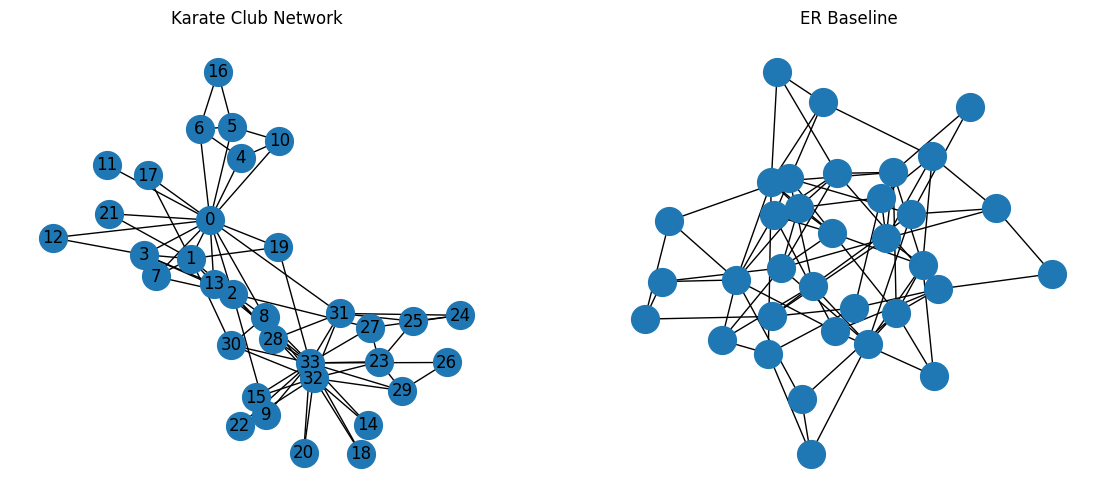

In [ ]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
pos1 = nx.spring_layout(G, seed=42)
nx.draw(G, pos1, node_size=400, with_labels=True)
plt.title("Karate Club Network")

plt.subplot(1,2,2)
pos2 = nx.spring_layout(ER, seed=42)
nx.draw(ER, pos2, node_size=400)
plt.title("ER Baseline")

plt.show()



We compare the observed network with the ER baseline.

Questions:
- Is the real network more clustered?
- Is the degree distribution more unequal?
- Is the community structure stronger?
- Does the network contain meaningful local organization?


In [ ]:
print("Real clustering:", round(real_clustering, 4))
print("ER clustering:", round(er_clustering, 4))

print("\nReal maximum degree:", max(real_degrees))
print("ER maximum degree:", max(er_degrees))

print("\nReal average path length:", round(real_path_length, 4))
print("ER average path length:", round(er_path_length, 4))

Real clustering: 0.5706
ER clustering: 0.1205

Real maximum degree: 17
ER maximum degree: 8

Real average path length: 2.4082
ER average path length: 2.3512


## 10. Conclusion

The Karate Club network is not fully explained by random chance. Although the ER baseline has a similar number of nodes and approximately the same density, the real network typically shows stronger clustering and a more unequal degree distribution. A few members have substantially more connections than average, creating local leadership structure that is not expected in a purely random graph. The community structure observed in previous exercises also suggests organization beyond random edge formation. Overall, the known split of the club and the presence of tightly connected local groups appear stronger than what would be expected from an Erdős–Rényi random network with the same size and density.
